In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from pathlib import Path

In [5]:
# Set the data path
# data_path = '/data/cschmidt/excited_states/apply_energy_NNs/fr0_project/simulated_on_s2_charges/recalc_all_geoms_from_traj/train_all_10_correct_water'

# data_path = '/data/cschmidt/excited_states/apply_energy_NNs/fr0_project/simulated_on_s2_charges/model_all_10_sol_correct_energies/train_all_10_correct_water' # water 100% old new model
data_path = '/data/cschmidt/excited_states/apply_energy_NNs/fr0_project/simulated_on_s2_charges/model_all_10_sol_correct_energies/trained_all_10_old_new_water' # water 50% old new model


Found 10 solvent files:
1. acetone: /data/cschmidt/excited_states/apply_energy_NNs/fr0_project/simulated_on_s2_charges/model_all_10_sol_correct_energies/trained_all_10_old_new_water/acetone_nn_pred_energy_osc_str.dat
2. dmf: /data/cschmidt/excited_states/apply_energy_NNs/fr0_project/simulated_on_s2_charges/model_all_10_sol_correct_energies/trained_all_10_old_new_water/dmf_nn_pred_energy_osc_str.dat
3. meoh: /data/cschmidt/excited_states/apply_energy_NNs/fr0_project/simulated_on_s2_charges/model_all_10_sol_correct_energies/trained_all_10_old_new_water/meoh_nn_pred_energy_osc_str.dat
4. dmso: /data/cschmidt/excited_states/apply_energy_NNs/fr0_project/simulated_on_s2_charges/model_all_10_sol_correct_energies/trained_all_10_old_new_water/dmso_nn_pred_energy_osc_str.dat
5. hexane: /data/cschmidt/excited_states/apply_energy_NNs/fr0_project/simulated_on_s2_charges/model_all_10_sol_correct_energies/trained_all_10_old_new_water/hexane_nn_pred_energy_osc_str.dat
6. dioxane: /data/cschmidt/excite

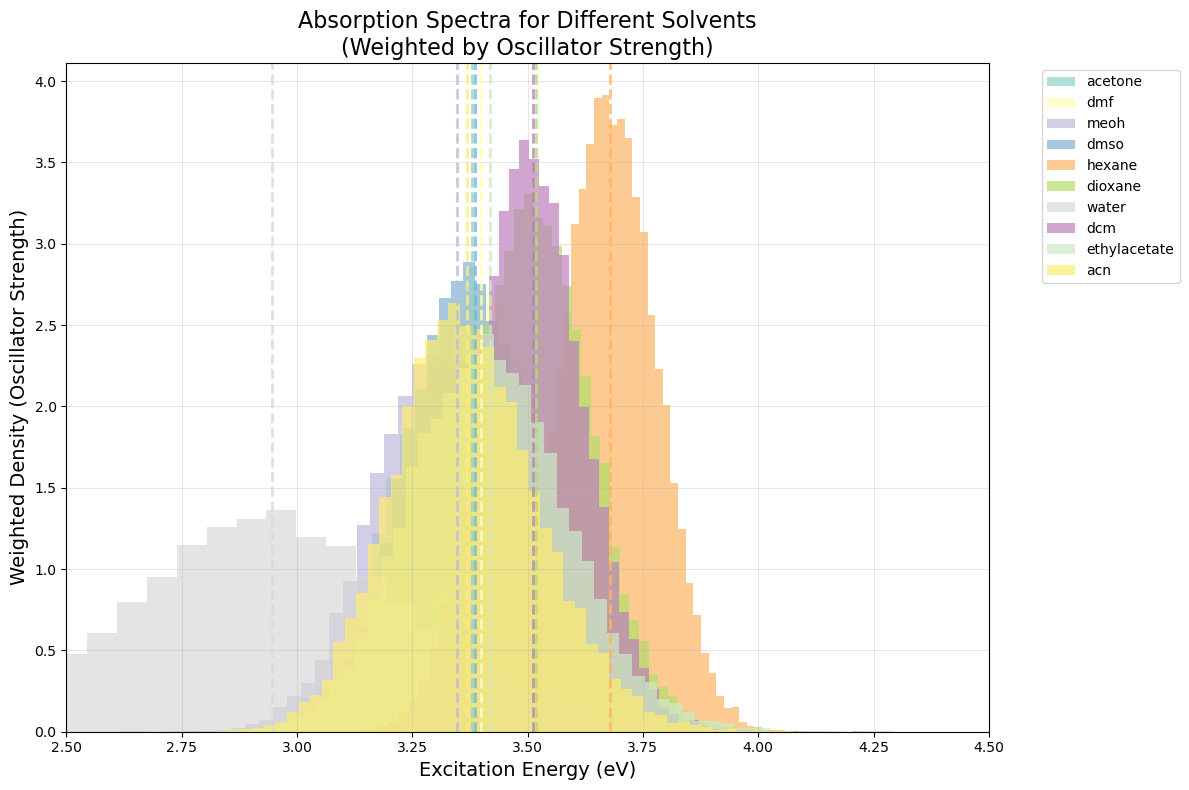

In [6]:
# Find all energy_osc_str.dat files
file_pattern = os.path.join(data_path, '*_nn_pred_energy_osc_str.dat')
# file_pattern = os.path.join(data_path, '*_energy_osc_str.txt')
files = glob.glob(file_pattern)

# Extract solvent names from filenames
solvent_names = []
for file in files:
    basename = os.path.basename(file)
    solvent = basename.split('_nn_pred_energy_osc_str.dat')[0]
    solvent_names.append(solvent)

print(f"Found {len(files)} solvent files:")
for i, (file, solvent) in enumerate(zip(files, solvent_names)):
    print(f"{i+1}. {solvent}: {file}")

# Create the plot
plt.figure(figsize=(12, 8))

# Define colors for different solvents
colors = plt.cm.Set3(np.linspace(0, 1, len(files)))

# Process each file
for i, (file, solvent, color) in enumerate(zip(files, solvent_names, colors)):
    try:
        # Load data (skip header line)
        data = np.loadtxt(file, skiprows=1)
        energies = data[:, 0]  # First column: energies in eV
        osc_strengths = data[:, 1]  # Second column: oscillator strengths
        
        print(f"\nProcessing {solvent}:")
        print(f"  Number of data points: {len(energies)}")
        print(f"  Energy range: {energies.min():.2f} - {energies.max():.2f} eV")
        print(f"  Oscillator strength range: {osc_strengths.min():.3f} - {osc_strengths.max():.3f}")
        
        # Calculate weighted mean
        weighted_mean = np.average(energies, weights=osc_strengths)
        print(f"  Weighted mean energy: {weighted_mean:.2f} eV")
        
        # Create weighted histogram
        plt.hist(energies, bins=50, weights=osc_strengths, alpha=0.7, 
                label=solvent, color=color, density=True)
        
        # Add vertical line for weighted mean
        plt.axvline(weighted_mean, color=color, linestyle='--', linewidth=2, alpha=0.8)
        
    except Exception as e:
        print(f"Error processing {solvent}: {e}")
        continue

# Customize the plot
plt.xlabel('Excitation Energy (eV)', fontsize=14)
plt.ylabel('Weighted Density (Oscillator Strength)', fontsize=14)
plt.title('Absorption Spectra for Different Solvents\n(Weighted by Oscillator Strength)', fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Set reasonable x-axis limits
plt.xlim(2.5, 4.5)  # Adjust based on your data range

# Save the plot
output_file = os.path.join(data_path, 'absorption_spectra_all_solvents.png')
plt.savefig(output_file, dpi=300, bbox_inches='tight')
plt.show()